<a href="https://colab.research.google.com/github/shyamgadhiya/ML-DL-Tasks/blob/main/Multi_Class_Sentiment_Analysis_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Multi-Class Sentiment Analysis Using LSTM**

## Dataset Overview
* Dataset Link : https://www.kaggle.com/datasets/abdelmalekeladjelet/sentiment-analysis-dataset/data
* dataset is a large-scale collection of 241,000+ English-language comments sourced from various online platforms. Each comment is annotated with a sentiment label: 0 — Negative, 1 — Neutral, 2 — Positive


In [ ]:
import pandas as pd

# Assuming the uploaded dataset is a CSV file named 'dataset.csv'
df = pd.read_csv('sentiment_data.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,Unnamed: 0,Comment,Sentiment
0,0,lets forget apple pay required brand new iphon...,1
1,1,nz retailers don’t even contactless credit car...,0
2,2,forever acknowledge channel help lessons ideas...,2
3,3,whenever go place doesn’t take apple pay doesn...,0
4,4,apple pay convenient secure easy use used kore...,2


## Data Preprocessing

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 241145 entries, 0 to 241144
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Unnamed: 0  241145 non-null  int64 
 1   Comment     240928 non-null  object
 2   Sentiment   241145 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 5.5+ MB


In [ ]:
df.isna().sum()

,0
Unnamed: 0,0
Comment,217
Sentiment,0


In [ ]:
df.shape

(241145, 3)

In [ ]:
print(f"Initial shape: {df.shape}")

# Drop rows with any null values
df.dropna(inplace=True)
print(f"Shape after dropping nulls: {df.shape}")

# Drop duplicated rows
df.drop_duplicates(inplace=True)
print(f"Shape after dropping duplicates: {df.shape}")

Initial shape: (241145, 3)
Shape after dropping nulls: (240928, 3)
Shape after dropping duplicates: (240928, 3)


## Visualize Dataset

/tmp/ipykernel_499/2403126732.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


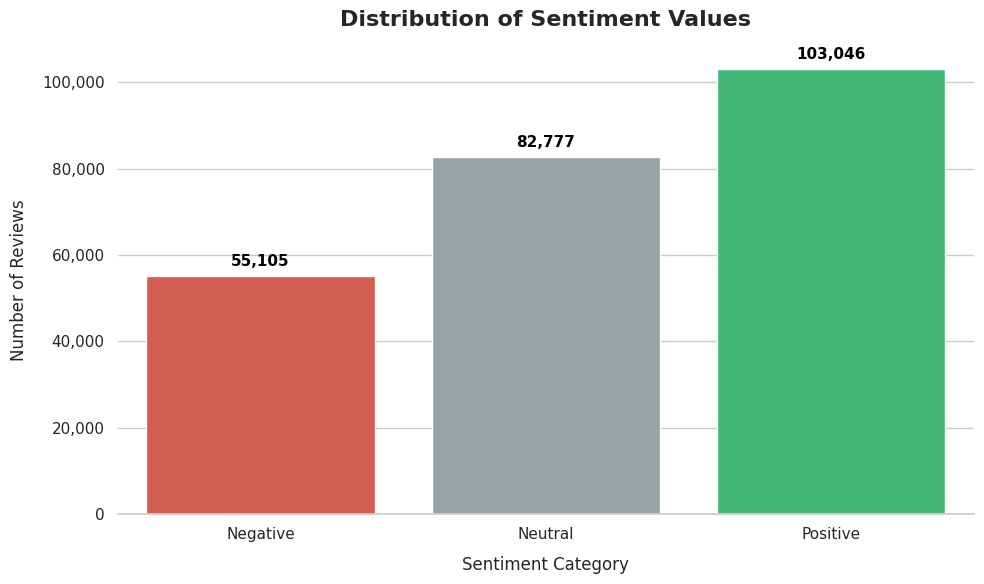

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# 1. Map numerical sentiments to descriptive labels (assuming standard 0,1,2 mapping)
sentiment_mapping = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
df['Sentiment_Label'] = df['Sentiment'].map(sentiment_mapping)

# 2. Set a clean, modern aesthetic with a horizontal grid
sns.set_theme(style="whitegrid")

# 3. Create the figure
plt.figure(figsize=(10, 6))

# 4. Define an intuitive color palette
custom_palette = {'Negative': '#e74c3c', 'Neutral': '#95a5a6', 'Positive': '#2ecc71'}

# 5. Plot the data
ax = sns.countplot(
    x='Sentiment_Label',
    data=df,
    palette=custom_palette,
    order=['Negative', 'Neutral', 'Positive'] # Ensure logical order
)

# 6. Enhance titles and axis labels
plt.title('Distribution of Sentiment Values', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Sentiment Category', fontsize=12, labelpad=10)
plt.ylabel('Number of Reviews', fontsize=12, labelpad=10)

# 7. Add direct data labels on top of each bar
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height):,}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontsize=11, color='black', fontweight='bold',
                xytext=(0, 5),
                textcoords='offset points')

# 8. Format y-axis to show commas for thousands
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: format(int(x), ',')))

# 9. Remove top and right borders (spines) to reduce ink clutter
sns.despine(left=True)

# 10. Adjust layout and show
plt.tight_layout()
plt.show()

## Text Preprocessing

In [ ]:
import re

def preprocess_text(text):
    if not isinstance(text, str):
        return ""

    # 1. Lowercasing
    text = text.lower()

    # 2. Noise Removal (URLs, HTML tags, special characters)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # URLs
    text = re.sub(r'<.*?>', '', text) # HTML tags
    text = re.sub(r'[^a-z\s]', '', text) # Remove special characters and numbers, keeping only letters

    return text.strip()

# Apply the preprocessing to the 'Comment' column
df['Processed_Comment'] = df['Comment'].apply(preprocess_text)

# Display the original and processed comments
display(df[['Comment', 'Processed_Comment']].head())

,Comment,Processed_Comment
0,lets forget apple pay required brand new iphon...,lets forget apple pay required brand new iphon...
1,nz retailers don’t even contactless credit car...,nz retailers dont even contactless credit card...
2,forever acknowledge channel help lessons ideas...,forever acknowledge channel help lessons ideas...
3,whenever go place doesn’t take apple pay doesn...,whenever go place doesnt take apple pay doesnt...
4,apple pay convenient secure easy use used kore...,apple pay convenient secure easy use used kore...


In [ ]:
from sklearn.model_selection import train_test_split

X = df['Processed_Comment']
y =  df['Sentiment'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

Train: 192742 | Test: 48186


In [ ]:

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)


In [ ]:
max_len = 100

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')
print(X_train_pad.shape, X_test_pad.shape)

(192742, 100) (48186, 100)


## Build LSTM Model

In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

In [ ]:
from tensorflow.keras.layers import Dropout

vocab_size = len(tokenizer.word_index) + 1
embedding_dim = 128

lstm_model = Sequential([
    # 1. Embedding Layer
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),

    # 2. LSTM Layer
    LSTM(64),

    # 3. Dropout Layer
    Dropout(0.2),

    # 4. Dense Layer
    Dense(32, activation='relu'),

    # 5. Last Softmax Layer (3 units for Negative, Neutral, Positive)
    Dense(3, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

lstm_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = lstm_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=64,)

Epoch 1/15
2410/2410 ━━━━━━━━━━━━━━━━━━━━ 47s 18ms/step - accuracy: 0.4275 - loss: 1.0686 - val_accuracy: 0.4283 - val_loss: 1.0694
Epoch 2/15
2410/2410 ━━━━━━━━━━━━━━━━━━━━ 46s 19ms/step - accuracy: 0.4276 - loss: 1.0680 - val_accuracy: 0.4284 - val_loss: 1.0682
Epoch 3/15
2410/2410 ━━━━━━━━━━━━━━━━━━━━ 43s 18ms/step - accuracy: 0.4278 - loss: 1.0678 - val_accuracy: 0.4286 - val_loss: 1.0680
Epoch 4/15
2410/2410 ━━━━━━━━━━━━━━━━━━━━ 44s 18ms/step - accuracy: 0.4279 - loss: 1.0676 - val_accuracy: 0.4285 - val_loss: 1.0683
Epoch 5/15
2410/2410 ━━━━━━━━━━━━━━━━━━━━ 43s 18ms/step - accuracy: 0.4281 - loss: 1.0673 - val_accuracy: 0.4284 - val_loss: 1.0684
Epoch 6/15
2410/2410 ━━━━━━━━━━━━━━━━━━━━ 44s 18ms/step - accuracy: 0.4281 - loss: 1.0671 - val_accuracy: 0.4285 - val_loss: 1.0687
Epoch 7/15
2410/2410 ━━━━━━━━━━━━━━━━━━━━ 82s 18ms/step - accuracy: 0.4281 - loss: 1.0671 - val_accuracy: 0.4285 - val_loss: 1.0693
Epoch 8/15
2410/2410 ━━━━━━━━━━━━━━━━━━━━ 82s 18ms/step - accuracy: 0.4281 -

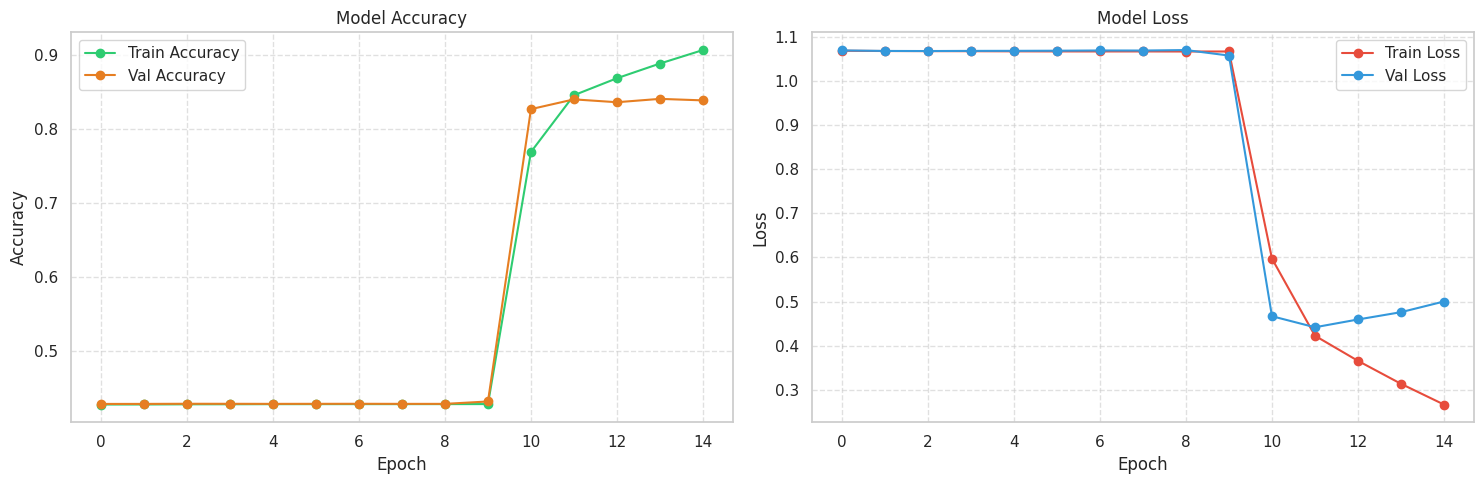

In [ ]:
import matplotlib.pyplot as plt

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot Accuracy
ax1.plot(history.history['accuracy'], label='Train Accuracy', color='#2ecc71', marker='o')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy', color='#e67e22', marker='o')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot Loss
ax2.plot(history.history['loss'], label='Train Loss', color='#e74c3c', marker='o')
ax2.plot(history.history['val_loss'], label='Val Loss', color='#3498db', marker='o')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
# Evaluate the model on the test set
test_loss, test_acc = lstm_model.evaluate(X_test_pad, y_test, verbose=0)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Test Loss: 0.4923
Test Accuracy: 0.8409


## After traing Simple LSTM model achieved 84% validation Accuracy.

1506/1506 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step
Classification Report:
              precision    recall  f1-score   support

    Negative       0.82      0.76      0.79     11021
     Neutral       0.80      0.89      0.84     16556
    Positive       0.89      0.85      0.87     20609

    accuracy                           0.84     48186
   macro avg       0.84      0.83      0.83     48186
weighted avg       0.84      0.84      0.84     48186



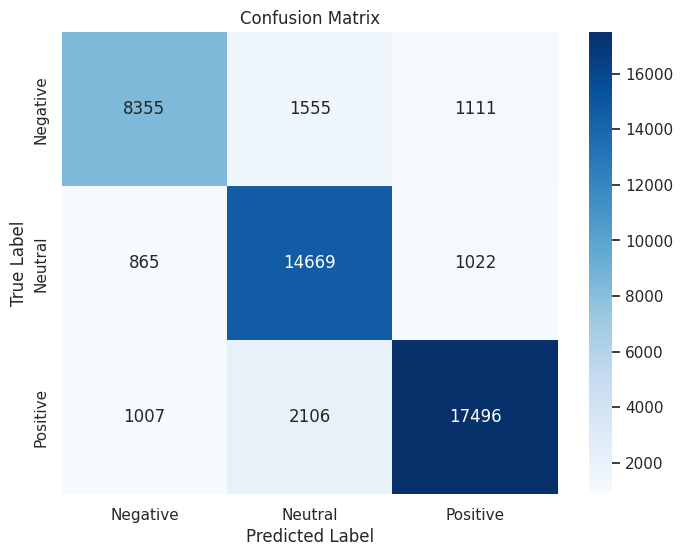

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Get model predictions for the test set
y_pred_probs = lstm_model.predict(X_test_pad)
y_pred = np.argmax(y_pred_probs, axis=1)

# Print the classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Neutral', 'Positive']))

# Plot the confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Prediction

In [ ]:
def predict_sentiment(text):
    # 1. Preprocess the input text
    cleaned_text = preprocess_text(text)

    # 2. Tokenize and pad
    sequence = tokenizer.texts_to_sequences([cleaned_text])
    padded = pad_sequences(sequence, maxlen=max_len, padding='post')

    # 3. Predict
    prediction = lstm_model.predict(padded, verbose=0)
    class_idx = np.argmax(prediction)

    # 4. Map to label
    labels = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
    return labels[class_idx]

# --- Test Examples ---
test_comments = [
    "I absolutely love this new feature, it works perfectly!",
    "The service was okay, nothing special but not bad either.",
    "This is the worst experience I have ever had with a product."
]

for comment in test_comments:
    sentiment = predict_sentiment(comment)
    print(f"Comment: {comment}")
    print(f"Predicted Sentiment: {sentiment}\n")

Comment: I absolutely love this new feature, it works perfectly!
Predicted Sentiment: Positive

Comment: The service was okay, nothing special but not bad either.
Predicted Sentiment: Neutral

Comment: This is the worst experience I have ever had with a product.
Predicted Sentiment: Negative

